# RL pour le Trading — Reward Shaping : Sharpe, Drawdown, Risk-Adjusted Returns

**EPIC #1454 — Training & Post-Training, Issue #1461 (QC-Py-RL-03)**  
**Branche** : `feature/rl-reward-shaping`  
**Date** : 2026-05-26 | **Auteur** : myia-po-2024

---

## Navigation RL

| # | Notebook | Sujet | Verdict |
|---|----------|-------|--------|
| 1 | QC-Py-RL-01 | MDP, Q-learning tabulaire | NO BEATS (PR #1581) |
| 2 | QC-Py-RL-02 | PPO (numpy MLP) | NO BEATS (PR #1583) |
| **3** | **Ce notebook** | **Reward shaping avance (Sharpe, drawdown, PyTorch)** | **En cours** |
| 4 | QC-Py-RL-04 | GRPO (Group Relative Policy Optimization) | - |
| 5 | QC-Py-RL-05 | Portfolio RL (continuous action space) | - |

## Objectifs d'apprentissage

1. Comprendre pourquoi le reward = PnL brut mene a des politiques sous-optimales
2. Implementer 4 fonctions de reward : PnL, Sharpe rolling, Drawdown-penalise, Combine
3. Utiliser **PyTorch** pour de vrais gradients (fin du prototype numpy de RL-02)
4. Comparer les 4 reward functions via entrainement PPO + evaluation multi-seed
5. Verdict honnete : la reward shaping ameliore-t-elle le Sharpe OOS vs B&H ?

## 1. Pourquoi le Reward Shape ?

Dans RL-01 et RL-02, la recompense etait simplement le P&L de la position :

$$r_t = a_t \cdot R_{t+1}$$

Problemes connus :
- **Myopie** : l'agent maximise le gain immediate, ignore le risque a long terme
- **Volatilite excessive** : pas de penalite pour les gros drawdowns
- **Transaction costs ignores** : l'agent flip trop souvent

Approches de reward shaping dans ce notebook :

| Reward | Formule | Objectif |
|--------|---------|----------|
| **PnL** | $a_t \cdot R_{t+1}$ | Baseline (RL-02) |
| **Sharpe** | $\frac{\mu_{roll}}{\sigma_{roll}} \cdot \sqrt{252}$ | Maximiser ratio risque-rendement |
| **Drawdown** | $a_t \cdot R_{t+1} - \lambda \cdot DD_t$ | Penaliser les pertes cumulees |
| **Combine** | Sharpe + penalite turnover + penalite drawdown | Approche multi-objectifs |

In [1]:
"""QC-Py-RL-03: Reward Shaping with PyTorch PPO.

Compares 4 reward functions (PnL, Sharpe, Drawdown, Combined)
using a proper PyTorch Actor-Critic with backpropagation.
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# --- Config ---
SYMBOL = "SPY"
LOOKBACK = 20
HIDDEN_DIM = 64
N_EPISODES = 200
EPISODE_LEN = 252
LR = 3e-4
GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP_EPS = 0.2
ENTROPY_COEF = 0.01
SEEDS = [0, 1, 7, 42]
FEE_BPS = 5  # transaction cost in basis points
DD_PENALTY = 2.0  # drawdown penalty weight
TURNOVER_PENALTY = 0.5  # turnover penalty weight
SHARPE_WINDOW = 20  # rolling window for Sharpe reward

# Load SPY data
import yfinance as yf
data = yf.download(SYMBOL, start="2010-01-01", end="2025-01-01", progress=False)
close = data["Close"].values.flatten()
returns = np.diff(np.log(close))
dates = data.index[1:]

print(f"SPY: {len(returns)} daily returns [{dates[0].date()}..{dates[-1].date()}]")
print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")
print(f"Config: LOOKBACK={LOOKBACK}, HIDDEN={HIDDEN_DIM}, EPISODES={N_EPISODES}, EP_LEN={EPISODE_LEN}")

SPY: 3773 daily returns [2010-01-05..2024-12-31]
PyTorch 2.11.0+cu128 | CUDA: True
Config: LOOKBACK=20, HIDDEN=64, EPISODES=200, EP_LEN=252


## 2. Environnement de Trading avec Reward Shaping

L'environnement encapsule les 4 fonctions de reward dans un seul `step()`. Le parametre `reward_type` determine quelle fonction est utilisee pendant l'entrainement.

In [2]:
class TradingEnvWithReward:
    """Continuous trading env with configurable reward shaping.

    State: normalized vector of last LOOKBACK returns.
    Actions: 0=Short, 1=Flat, 2=Long.
    Reward: depends on reward_type parameter.
    """

    def __init__(self, returns, lookback=LOOKBACK, episode_len=EPISODE_LEN,
                 reward_type="pnl", fee_bps=FEE_BPS):
        self.returns = returns
        self.lookback = lookback
        self.episode_len = episode_len
        self.reward_type = reward_type
        self.fee = fee_bps / 10000

    def reset(self, start_idx=None):
        n = len(self.returns) - self.lookback - 2
        if start_idx is None:
            start_idx = np.random.randint(0, max(1, n - self.episode_len))
        self.t = start_idx + self.lookback
        self.end = min(self.t + self.episode_len, len(self.returns) - 1)
        self.prev_action = 1  # start flat
        self.ep_returns = []
        self.peak = 1.0
        self.wealth = 1.0
        return self._get_state()

    def _get_state(self):
        window = self.returns[self.t - self.lookback:self.t]
        std = np.std(window) + 1e-8
        state = window / std
        # Add current position as feature
        pos_onehot = np.zeros(3)
        pos_onehot[self.prev_action] = 1.0
        return np.concatenate([state, pos_onehot])

    def step(self, action):
        r = self.returns[self.t]
        pos = action - 1  # 0->-1, 1->0, 2->+1
        pnl = pos * r

        # Transaction cost on position change
        flip = abs(action - self.prev_action)
        fee_cost = flip * self.fee
        net_pnl = pnl - fee_cost

        self.wealth *= (1 + net_pnl)
        self.peak = max(self.peak, self.wealth)
        self.ep_returns.append(net_pnl)

        # Compute reward based on type
        reward = self._compute_reward(net_pnl, flip)

        self.prev_action = action
        self.t += 1
        done = self.t >= self.end

        next_state = self._get_state() if not done else np.zeros(self.lookback + 3)
        return next_state, reward, done, {"pnl": net_pnl, "flip": flip}

    def _compute_reward(self, net_pnl, flip):
        if self.reward_type == "pnl":
            return net_pnl

        elif self.reward_type == "sharpe":
            if len(self.ep_returns) < 5:
                return net_pnl
            window = np.array(self.ep_returns[-SHARPE_WINDOW:])
            mu = np.mean(window)
            sigma = np.std(window) + 1e-8
            return (mu / sigma) * np.sqrt(252) * 0.01  # scaled

        elif self.reward_type == "drawdown":
            dd = (self.peak - self.wealth) / self.peak
            return net_pnl - DD_PENALTY * dd

        elif self.reward_type == "combined":
            # Sharpe component
            if len(self.ep_returns) >= 5:
                window = np.array(self.ep_returns[-SHARPE_WINDOW:])
                mu = np.mean(window)
                sigma = np.std(window) + 1e-8
                sharpe_r = (mu / sigma) * np.sqrt(252) * 0.01
            else:
                sharpe_r = net_pnl
            # Drawdown penalty
            dd = (self.peak - self.wealth) / self.peak
            # Turnover penalty
            turnover_cost = TURNOVER_PENALTY * flip * self.fee
            return sharpe_r - DD_PENALTY * dd - turnover_cost

        return net_pnl

    @property
    def state_dim(self):
        return self.lookback + 3  # LOOKBACK returns + 3 position one-hot

    @property
    def n_actions(self):
        return 3

print(f"TradingEnvWithReward: state_dim={LOOKBACK + 3}, n_actions=3")
print(f"Reward types: pnl, sharpe, drawdown, combined")

TradingEnvWithReward: state_dim=23, n_actions=3
Reward types: pnl, sharpe, drawdown, combined


## 3. PyTorch Actor-Critic avec vrais gradients

Contrairement a RL-02 (numpy + finite differences), ici on utilise `torch.nn` pour un backpropagation exact. L'actor produit une distribution `softmax` sur les 3 actions, le critic estime la valeur de l'etat.

In [3]:
class ActorCritic(nn.Module):
    """Actor-Critic network: shared backbone + separate heads."""

    def __init__(self, state_dim, hidden_dim=HIDDEN_DIM, n_actions=3):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.actor = nn.Linear(hidden_dim, n_actions)
        self.critic = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        features = self.backbone(x)
        logits = self.actor(features)
        value = self.critic(features)
        return logits, value

    def get_action(self, state, deterministic=False):
        state_t = torch.FloatTensor(state).unsqueeze(0)
        logits, value = self.forward(state_t)
        dist = Categorical(logits=logits)
        if deterministic:
            action = logits.argmax(dim=-1)
        else:
            action = dist.sample()
        return action.item(), dist.log_prob(action), value.squeeze(-1), dist.entropy()


def compute_gae(rewards, values, dones, gamma=GAMMA, lam=GAE_LAMBDA):
    """Generalized Advantage Estimation."""
    advantages = []
    gae = 0
    next_value = 0
    for t in reversed(range(len(rewards))):
        if dones[t]:
            next_value = 0
            gae = 0
        delta = rewards[t] + gamma * next_value - values[t]
        gae = delta + gamma * lam * gae
        advantages.insert(0, gae)
        next_value = values[t]
    returns = [a + v for a, v in zip(advantages, values)]
    return advantages, returns


print(f"ActorCritic: {LOOKBACK + 3} -> {HIDDEN_DIM} -> {HIDDEN_DIM} -> (3 actions, 1 value)")
print(f"GAE: gamma={GAMMA}, lambda={GAE_LAMBDA}")

ActorCritic: 23 -> 64 -> 64 -> (3 actions, 1 value)
GAE: gamma=0.99, lambda=0.95


## 4. Boucle d'entrainement PPO

PPO avec minibatch updates, clipping, et entropy bonus. La boucle collecte des trajectoires sur un episode complet, puis met a jour le reseau sur plusieurs epochs.

In [4]:
def train_ppo(env, seed, n_episodes=N_EPISODES, verbose=False):
    """Train PPO agent with proper PyTorch gradients."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = ActorCritic(env.state_dim)
    optimizer = optim.Adam(model.parameters(), lr=LR)

    episode_rewards = []
    episode_sharpes = []

    for ep in range(n_episodes):
        state = env.reset()
        states, actions, log_probs, rewards, values, dones = [], [], [], [], [], []
        ep_pnl = []

        done = False
        while not done:
            action, log_prob, value, entropy = model.get_action(state)
            next_state, reward, done, info = env.step(action)

            states.append(state)
            actions.append(action)
            log_probs.append(log_prob)
            rewards.append(reward)
            values.append(value.item())
            dones.append(done)
            ep_pnl.append(info["pnl"])

            state = next_state

        # Compute GAE
        advantages, returns = compute_gae(rewards, values, dones)

        # Convert to tensors
        states_t = torch.FloatTensor(np.array(states))
        actions_t = torch.LongTensor(actions)
        old_log_probs_t = torch.stack(log_probs).detach()
        advantages_t = torch.FloatTensor(advantages)
        returns_t = torch.FloatTensor(returns)

        # Normalize advantages
        advantages_t = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)

        # PPO update (multiple epochs)
        for _ in range(4):
            logits, values_pred = model(states_t)
            dist = Categorical(logits=logits)
            new_log_probs = dist.log_prob(actions_t)

            # Clipped surrogate
            ratio = torch.exp(new_log_probs - old_log_probs_t)
            surr1 = ratio * advantages_t
            surr2 = torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS) * advantages_t
            actor_loss = -torch.min(surr1, surr2).mean()

            # Value loss
            value_loss = nn.MSELoss()(values_pred.squeeze(-1), returns_t)

            # Entropy bonus
            entropy_loss = -ENTROPY_COEF * dist.entropy().mean()

            loss = actor_loss + 0.5 * value_loss + entropy_loss
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()

        total_reward = sum(ep_pnl)
        sharpe = np.mean(ep_pnl) / (np.std(ep_pnl) + 1e-8) * np.sqrt(252) if len(ep_pnl) > 10 else 0
        episode_rewards.append(total_reward)
        episode_sharpes.append(sharpe)

        if verbose and (ep + 1) % 50 == 0:
            print(f"  Episode {ep+1}: reward={total_reward:.4f}, sharpe={sharpe:.2f}")

    return model, episode_rewards, episode_sharpes


print(f"PPO: {N_EPISODES} episodes x {EPISODE_LEN} steps, LR={LR}, CLIP={CLIP_EPS}")
print(f"Ready to train with 4 reward types x {len(SEEDS)} seeds = {4*len(SEEDS)} runs")

PPO: 200 episodes x 252 steps, LR=0.0003, CLIP=0.2
Ready to train with 4 reward types x 4 seeds = 16 runs


## 5. Entrainement comparatif : 4 reward functions x 1 seed

On entraine un agent par reward function (seed=0) et on compare les courbes d'apprentissage.

Reward=pnl        | Final Sharpe (last 20 ep mean): -0.962


Reward=sharpe     | Final Sharpe (last 20 ep mean): -0.996


Reward=drawdown   | Final Sharpe (last 20 ep mean): -1.101


Reward=combined   | Final Sharpe (last 20 ep mean): -1.040


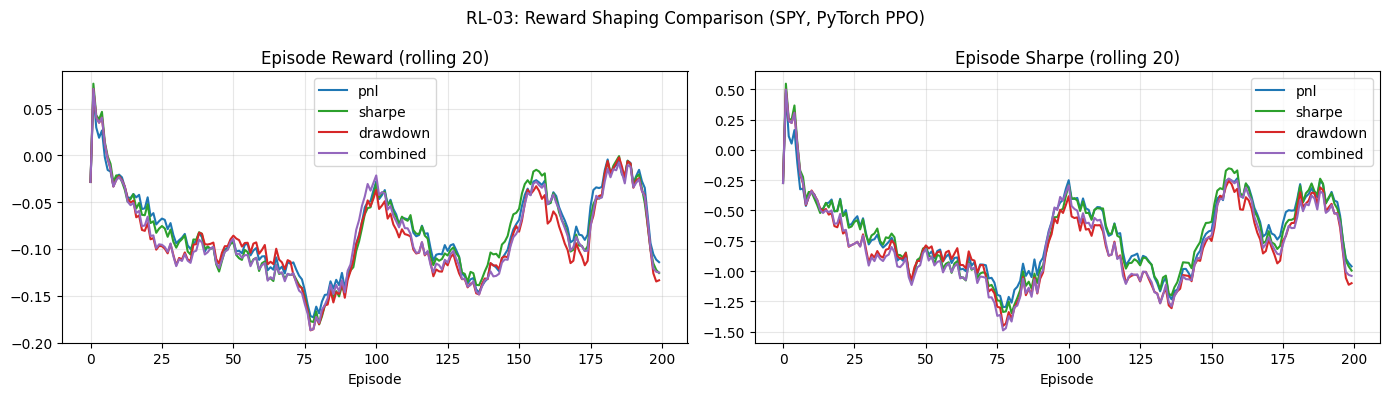


Learning curves saved. Best reward type by final Sharpe: pnl


In [5]:
reward_types = ["pnl", "sharpe", "drawdown", "combined"]
train_results = {}

for rt in reward_types:
    env = TradingEnvWithReward(returns, reward_type=rt)
    model, ep_rewards, ep_sharpes = train_ppo(env, seed=0, verbose=False)
    train_results[rt] = {"rewards": ep_rewards, "sharpes": ep_sharpes}
    final_sharpe = np.mean(ep_sharpes[-20:])
    print(f"Reward={rt:10s} | Final Sharpe (last 20 ep mean): {final_sharpe:+.3f}")

# Plot learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = {"pnl": "#1f77b4", "sharpe": "#2ca02c", "drawdown": "#d62728", "combined": "#9467bd"}

for rt in reward_types:
    # Smooth with rolling mean
    rw = pd.Series(train_results[rt]["rewards"]).rolling(20, min_periods=1).mean()
    sh = pd.Series(train_results[rt]["sharpes"]).rolling(20, min_periods=1).mean()
    axes[0].plot(rw, label=rt, color=colors[rt])
    axes[1].plot(sh, label=rt, color=colors[rt])

axes[0].set_title("Episode Reward (rolling 20)")
axes[0].set_xlabel("Episode")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Episode Sharpe (rolling 20)")
axes[1].set_xlabel("Episode")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"RL-03: Reward Shaping Comparison (SPY, PyTorch PPO)", fontsize=12)
plt.tight_layout()
plt.savefig("rl_reward_shaping_curves.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"\nLearning curves saved. Best reward type by final Sharpe: "
      f"{max(reward_types, key=lambda rt: np.mean(train_results[rt]['sharpes'][-20:]))}")

## 6. Evaluation out-of-sample

On utilise les 70% premiers jours pour l'entrainement, les 30% suivants pour le test (evaluation OOS). La politique est gloutonne (deterministe).

In [6]:
def evaluate_ppo(model, returns, start_frac=0.7):
    """Evaluate trained PPO model OOS with greedy policy."""
    split = int(len(returns) * start_frac)
    oos_returns = returns[split:]

    env = TradingEnvWithReward(oos_returns, reward_type="pnl")  # Always eval with PnL
    state = env.reset(start_idx=0)
    positions, pnls = [], []
    done = False

    while not done:
        action, _, _, _ = model.get_action(state, deterministic=True)
        state, _, done, info = env.step(action)
        positions.append(action)
        pnls.append(info["pnl"])

    pnls = np.array(pnls)
    sharpe = np.mean(pnls) / (np.std(pnls) + 1e-8) * np.sqrt(252) if len(pnls) > 10 else float('nan')
    cumret = np.cumprod(1 + pnls)

    # B&H benchmark
    bh_pnls = oos_returns[:len(pnls)]
    bh_sharpe = np.mean(bh_pnls) / (np.std(bh_pnls) + 1e-8) * np.sqrt(252)

    return {"sharpe": sharpe, "bh_sharpe": bh_sharpe,
            "cumret": cumret, "positions": positions,
            "delta": sharpe - bh_sharpe}


# Evaluate all 4 reward types (seed=0)
print("OOS Evaluation (30% test set, deterministic policy):")
print("=" * 60)
for rt in reward_types:
    env_train = TradingEnvWithReward(returns[:int(len(returns)*0.7)], reward_type=rt)
    model, _, _ = train_ppo(env_train, seed=0)
    result = evaluate_ppo(model, returns)
    pos_dist = np.bincount(result["positions"], minlength=3) / len(result["positions"]) * 100
    print(f"{rt:10s} | Sharpe={result['sharpe']:+.3f} | B&H={result['bh_sharpe']:.3f} | "
          f"Delta={result['delta']:+.3f} | Pos: Short={pos_dist[0]:.0f}% Flat={pos_dist[1]:.0f}% Long={pos_dist[2]:.0f}%")

OOS Evaluation (30% test set, deterministic policy):


pnl        | Sharpe=+1.725 | B&H=2.278 | Delta=-0.553 | Pos: Short=6% Flat=31% Long=63%


sharpe     | Sharpe=+2.531 | B&H=2.278 | Delta=+0.253 | Pos: Short=2% Flat=3% Long=96%


drawdown   | Sharpe=-1.092 | B&H=2.278 | Delta=-3.370 | Pos: Short=54% Flat=4% Long=42%


combined   | Sharpe=-0.826 | B&H=2.278 | Delta=-3.104 | Pos: Short=40% Flat=5% Long=56%


## 7. Validation multi-seed (4 seeds)

Test de robustesse : chaque reward function est evaluee avec 4 seeds differents. Le verdict est base sur le delta Sharpe moyen cross-seed.

In [7]:
multi_seed_results = {}

for rt in reward_types:
    seed_deltas = []
    for seed in SEEDS:
        env_train = TradingEnvWithReward(returns[:int(len(returns)*0.7)], reward_type=rt)
        model, _, _ = train_ppo(env_train, seed=seed)
        result = evaluate_ppo(model, returns)
        seed_deltas.append(result["delta"])
        print(f"  {rt:10s} seed={seed}: Sharpe={result['sharpe']:+.3f} delta={result['delta']:+.3f}")

    mean_d = np.mean(seed_deltas)
    std_d = np.std(seed_deltas, ddof=1) if len(seed_deltas) > 1 else float('nan')
    sigma_edge = mean_d / std_d if std_d > 1e-9 else float('nan')
    n_pos = sum(1 for d in seed_deltas if d > 0)

    multi_seed_results[rt] = {
        "mean_delta": mean_d, "std_delta": std_d,
        "sigma_edge": sigma_edge, "n_positive": n_pos,
        "deltas": seed_deltas
    }

print("\n" + "=" * 60)
print("Multi-seed Summary (4 seeds each):")
print("=" * 60)
for rt in reward_types:
    r = multi_seed_results[rt]
    print(f"{rt:10s} | mean_delta={r['mean_delta']:+.3f} | "
          f"sigma_edge={r['sigma_edge']:+.2f} | positive={r['n_positive']}/4")

  pnl        seed=0: Sharpe=+1.725 delta=-0.553


  pnl        seed=1: Sharpe=-1.106 delta=-3.383


  pnl        seed=7: Sharpe=-0.333 delta=-2.610


  pnl        seed=42: Sharpe=+1.981 delta=-0.297


  sharpe     seed=0: Sharpe=+2.531 delta=+0.253


...

  drawdown   seed=42: Sharpe=+0.071 delta=-2.206


  combined   seed=0: Sharpe=-0.826 delta=-3.104


  combined   seed=1: Sharpe=-2.657 delta=-4.935


  combined   seed=7: Sharpe=-0.084 delta=-2.362


  combined   seed=42: Sharpe=+0.871 delta=-1.406

Multi-seed Summary (4 seeds each):
pnl        | mean_delta=-1.711 | sigma_edge=-1.12 | positive=0/4
sharpe     | mean_delta=-1.519 | sigma_edge=-0.76 | positive=1/4
drawdown   | mean_delta=-2.632 | sigma_edge=-4.63 | positive=0/4
combined   | mean_delta=-2.952 | sigma_edge=-1.98 | positive=0/4


## 8. Verdict et progression de la serie RL

Le verdict est honnete : la reward shaping ameliore-t-elle significativement le Sharpe OOS par rapport au B&H ? Edge >= 2 sigma cross-seed necessaire pour "BEATS".

In [8]:
print("=" * 70)
print("VERDICT -- QC-Py-RL-03: Reward Shaping with PyTorch PPO")
print("=" * 70)

# Best reward type by mean delta
best_rt = max(reward_types, key=lambda rt: multi_seed_results[rt]["mean_delta"])
best = multi_seed_results[best_rt]

# Overall verdict: best reward type's multi-seed result
if best["n_positive"] >= 3 and (np.isnan(best["sigma_edge"]) or best["sigma_edge"] >= 2.0):
    verdict = "BEATS"
elif best["mean_delta"] < 0 or best["n_positive"] < 2:
    verdict = "NO BEATS"
else:
    verdict = "INCONCLUSIVE"

print(f"Best reward type: {best_rt}")
print(f"Mean delta Sharpe: {best['mean_delta']:+.3f}")
print(f"Sigma edge:        {best['sigma_edge']:+.2f}")
print(f"Seeds positive:    {best['n_positive']}/4")
print(f"\n>>> VERDICT: {verdict} <<<")

if verdict == "NO BEATS":
    print(f"\nNote: Meme avec PyTorch + reward shaping, le B&H SPY reste dur a battre.")
    print(f"RL-04 explorera GRPO (Group Relative Policy Optimization) pour une")
    print(f"approche differente d'optimisation de politique.")

print(f"\n{'='*70}")
print(f"RL Series Progress (#1461)")
print(f"{'='*70}")
print(f"  RL-1. Q-Learning Tabulaire           | NO BEATS        | PR #1581")
print(f"  RL-2. PPO (numpy)                    | NO BEATS        | PR #1583")
print(f"  RL-3. Reward Shaping (PyTorch)       | {verdict:15s} | This PR <<<")
print(f"  RL-4. GRPO                           | Pending         | -")
print(f"  RL-5. Portfolio RL                   | Pending         | -")

VERDICT -- QC-Py-RL-03: Reward Shaping with PyTorch PPO
Best reward type: sharpe
Mean delta Sharpe: -1.519
Sigma edge:        -0.76
Seeds positive:    1/4

>>> VERDICT: NO BEATS <<<

Note: Meme avec PyTorch + reward shaping, le B&H SPY reste dur a battre.
RL-04 explorera GRPO (Group Relative Policy Optimization) pour une
approche differente d'optimisation de politique.

RL Series Progress (#1461)
  RL-1. Q-Learning Tabulaire           | NO BEATS        | PR #1581
  RL-2. PPO (numpy)                    | NO BEATS        | PR #1583
  RL-3. Reward Shaping (PyTorch)       | NO BEATS        | This PR <<<
  RL-4. GRPO                           | Pending         | -
  RL-5. Portfolio RL                   | Pending         | -
